# Implementacion del modelo de FitzHugh-Nagumo

Codigo de ejemplo en python para implementar el modelo FHN

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

from matplotlib.ticker import FuncFormatter

Grafica de Nullclines

In [162]:
# Definir las constantes globales
# a  = -1
# b  = -0.3
# c1 = 1.9
# c2 = 10
# d  = 1
# e  = 0.06
# A  = 33
# B  = -22
# k  = 10
# I  = 0.02

a  = -1.5
b  = -0.3
c1 = 50
c2 = 10
d  = 2
e  = 0.066
A  = 0.035
B  = -0.033
k  = 1
I  = 0.02

# a = -1.5    # cuando incrementa el valor absoluto de este, aumenta el periodo de la senal y el voltaje un poco
# b = -0.29   # cambia el tiempo de reposo, va reduciendo el tiempo de reposo, esto cuando es negativo, cuando es positivo, aumenta el tiempo de activacion
# c1 = 50     # cuando aumenta, aumenta el periodo sin afectar la amplitud 
# c2 = 10     # cuando aumenta, reduce el periodo sin afecar la amplitud
# d = 0
# e = 0.066   # cuando aumenta, disminuye el periodo
# A = 0.035   # aumenta la amplitud de la se�al al mismo tiempo que el periodo
# B = -0.03   # cambia el offset de la se�al
# k = 1       # controla el tiempo de calculo
# I = 20


# Definir las funciones
def rhsV(w, v, a, b, c1, c2, d, e, A, B, k):
    return k*c1*(v - B)*(((v-B)/A)-a)*(1-((v-B)/A))-k*c2*w    # parameterized function

def rhsW(w, v, a, b, c1, c2, d, e, A, B, k):
    return k*e*(((v-B)/A)-d*w-b)     # parameterized function


## Grafica de la trayectoria Nullclines

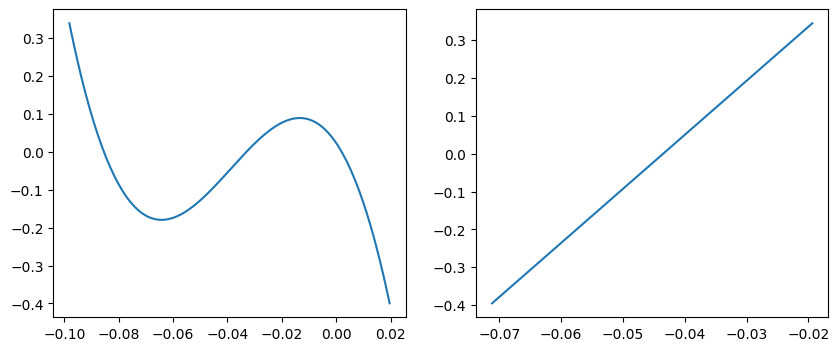

In [169]:
l1 = -0.4
l2 = 0.35

# Definir los rangos y listas de valores
vv = np.linspace(l1, l2, 1000)
nullv = []
nullw = []

# Función auxiliar para encontrar un intervalo adecuado
def find_root(func, bracket, v):
    try:
        root = root_scalar(func, bracket=bracket, args=(v), method='brentq', xtol=1e-6)
        if root.converged:
            return root.root
        else:
            return np.nan
    except ValueError:
        return np.nan


# Evaluar los nullclines
for v in vv:
    nullv.append(find_root(lambda w, v: rhsV(w, v, a, b, c1, c2, d, e, A, B, k), [l1, l2], v))
    nullw.append(find_root(lambda w, v: rhsW(w, v, a, b, c1, c2, d, e, A, B, k), [l1, l2], v))
    

# Convertir listas a arrays para facilitar la manipulación
nullv = np.array(nullv)
nullw = np.array(nullw)

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(vv,nullv)
plt.subplot(122)
plt.plot(vv,nullw)



In [171]:
# Constants for the method
dt = 0.001                  # delta time in ms
t = np.arange(0, 50, dt)   # time array in ms

Vsol = np.zeros(len(t))
Wsol = np.zeros(len(t))
Vsol[0] = np.array(-0.065)  # Valor inicial de la solucion
Wsol[0] = np.array(0)  # Valor inicial de la solucion


for i in range(0, len(t) - 1):

    # Euler method
    Vsol[i+1]= Vsol[i] + rhsV(Wsol[i], Vsol[i], a, b, c1, c2, d, e, A, B, k)*dt
    Wsol[i+1]= Wsol[i] + rhsW(Wsol[i], Vsol[i], a, b, c1, c2, d, e, A, B, k)*dt



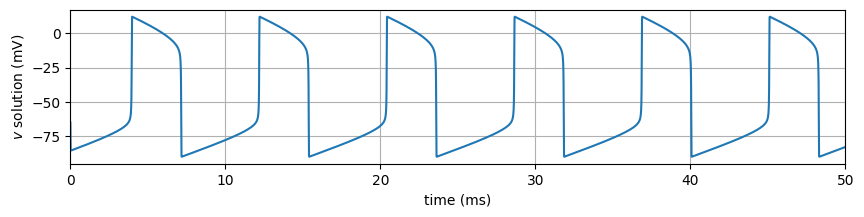

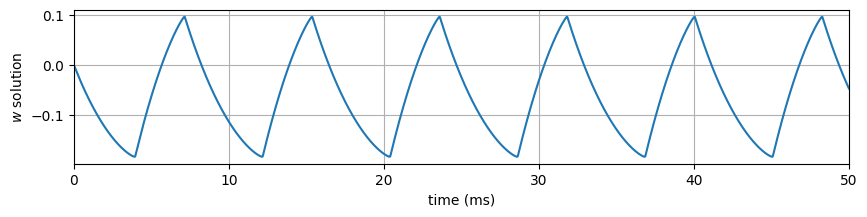

In [228]:
# Generar datos ficticios para T y Y
T = t
Y = np.zeros((len(t), 2))
Y[:, 0] = Vsol  # Datos ficticios para V, ajustar según sea necesario
Y[:, 1] = Wsol  # Datos ficticios para n, ajustar según sea necesario

plt.figure(figsize=(10,2))
plt.plot(T, Y[:,0]*1000)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$v$ solution (mV)')
plt.xlim([0, 50])
#plt.ylim([-80, 60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHNcar_v.pdf", format="pdf", bbox_inches="tight")


# 
plt.figure(figsize=(10,2))
plt.plot(T, Y[:,1])

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$w$ solution')
plt.xlim([0, 50])
#plt.ylim([0.3, 0.8])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHNcar_w.pdf", format="pdf", bbox_inches="tight")


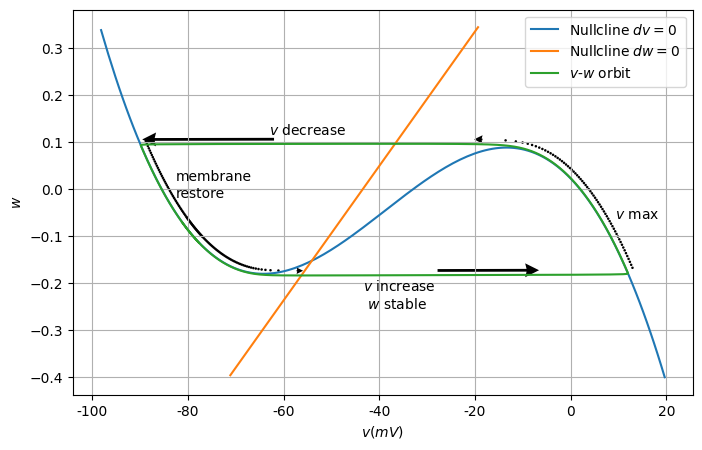

In [229]:
# Función para formatear los labels del eje x
def x_formatter(x, pos):
    return f'{x * 1000:.0f}'

# Calcular las diferencias entre puntos para las flechas
dY = np.diff(Y[:,:], axis=0)

# posicion de los labels
p1 = 3940
p2 = 5000
p3 = 7150
p4 = 250

# Definir el rango de interés
ini = 1000
fin = 10000

# Graficar los nullclines y la trayectoria
plt.figure(figsize=(8, 5))

# Nullclines
plt.plot(vv, nullv, label='Nullcline $dv=0$')
plt.plot(vv, nullw, label='Nullcline $dw=0$')

# Trayectoria
plt.plot(Y[ini:fin, 0], Y[ini:fin, 1], label='$v$-$w$ orbit')

# Flechas para indicar la dirección del tiempo
skip = 50  # saltar puntos para no sobrecargar el gráfico con flechas
arrow_offset = 0.001  # desplazamiento de las flechas

plt.quiver(Y[ini:fin-1:skip, 0] + arrow_offset, Y[ini:fin-1:skip, 1] + 10*arrow_offset, 
           dY[ini:fin:skip, 0], dY[ini:fin:skip, 1], 
           angles='xy', scale_units='xy', scale=.1, headwidth=5, headlength=5, color='black')

# Añadir etiquetas
plt.text(Y[p1, 0], Y[p1, 1] - 70*arrow_offset, '$v$ increase\n $w$ stable', fontsize=10)
plt.text(Y[p2, 0] + 3*arrow_offset, Y[p2, 1] , '$v$ max', fontsize=10)
plt.text(Y[p3, 0], Y[p3, 1] + 20*arrow_offset, '$v$ decrease', fontsize=10)
plt.text(Y[p4, 0]+ 2*arrow_offset, Y[p4, 1] + 2*arrow_offset, 'membrane\nrestore', fontsize=10)

# Personalizar los labels del eje x
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(x_formatter))

plt.xlabel('$v (mV)$')
plt.ylabel('$w$')
#plt.axis([-80, 60, 0, 1])
plt.legend()
#plt.title('Nullclines and Trajectory with Direction')
plt.grid(True)

#plt.show()

plt.savefig("output/vwcar-nullclines.pdf", format="pdf", bbox_inches="tight")

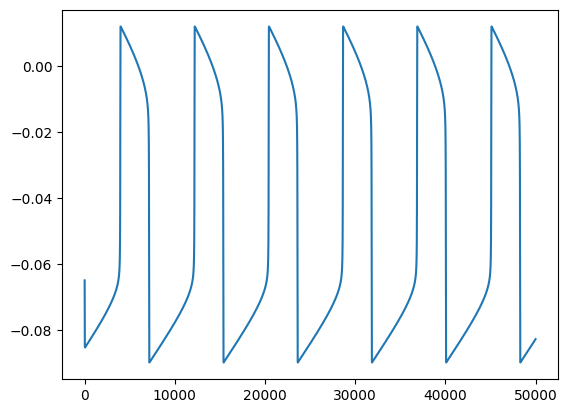

In [197]:
plt.plot(Vsol)